# 3주차 · 점수가 부풀려져 있었다

오늘은 새로운 추천 방법을 배우지 않습니다. **모델은 지난주 것을 한 글자도 고치지 않고 그대로 씁니다.**
바꾸는 것은 채점 방법뿐입니다.

그런데 점수가 떨어집니다. 점수가 떨어지는 것이 오늘의 목표입니다. 지금까지 우리가 보아 온 숫자가
실제보다 높았다는 것을 직접 확인하고, 왜 그런 일이 생기는지 알아봅니다.

In [1]:
# 준비 — 필요한 도구를 불러옵니다.
# recsys.py 는 모든 주차가 함께 쓰는 도구 상자입니다. 데이터를 읽는 방법, 데이터를 나누는 방법,
# 점수를 재는 방법이 여기에 한 번만 적혀 있습니다.
import sys

sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import recsys

# 맥에서 그래프의 한글이 깨지지 않게 합니다. 윈도우라면 "Malgun Gothic" 으로 바꾸세요.
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

print("준비 완료")

준비 완료


## 1. 데이터를 나누는 두 가지 방법

추천이 잘 되는지 재려면 데이터의 일부를 가려 두고, 나머지로만 배운 다음, 가려 둔 것을 맞혀야 합니다.
이때 **어떻게 가릴 것인가**에 두 가지 방법이 있습니다.

- **무작위로 나누기** — 전체 기록을 섞은 다음 일부를 떼어 놓습니다. 가장 흔히 쓰이고 코드도 한 줄입니다.
- **시간으로 나누기** — 마지막 한 달을 통째로 떼어 놓습니다. 우리가 1주차부터 써 온 방법입니다.

둘 중 어느 쪽이 맞을까요? 실제 서비스에서 우리는 **미래를 볼 수 없습니다.** 그런데 무작위로 나누면
8월의 기록으로 배워서 3월의 기록을 맞히는 일이 생깁니다. 시험 문제를 미리 본 것과 같은 상태가 됩니다.

말로만 하면 잘 와닿지 않으니 두 방법으로 각각 채점해서 숫자를 비교해 봅니다.

In [2]:
items, users, inter = recsys.load()
name_of = items.set_index("item_id")["name"].to_dict()
섹터_of = items.set_index("item_id")["sector"].to_dict()
위험도_of = items.set_index("item_id")["risk_level"].to_dict()


def 무리_만들기(학습구간):
    """2주차에서 만든 것과 똑같은 규칙. 주력 섹터와 평균 위험도로 사람을 묶는다."""
    주력섹터 = (학습구간.assign(s=학습구간["item_id"].map(섹터_of))
              .groupby("user_id")["s"].agg(lambda x: x.value_counts().index[0]).to_dict())
    평균위험도 = (학습구간.assign(r=학습구간["item_id"].map(위험도_of))
               .groupby("user_id")["r"].mean().round(0).astype(int).to_dict())
    return {u: f"{주력섹터[u]}|{평균위험도[u]}" for u in 주력섹터}


def 무리별_추천_만들기(학습구간):
    """2주차 모델을 그대로 만든다. 오늘 바꾸는 것은 이 함수가 아니라 학습구간이다."""
    무리 = 무리_만들기(학습구간)
    전체인기 = list(학습구간["item_id"].value_counts().index)
    순위표 = {g: list(v["item_id"].value_counts().index)
            for g, v in 학습구간.assign(g=학습구간["user_id"].map(무리)).groupby("g")}
    return lambda uid, seen: recsys.take(순위표.get(무리.get(uid), 전체인기), seen)

먼저 **무작위로** 나눠서 채점합니다. 전체 기록을 섞은 뒤 시간순 분할과 같은 크기만큼 떼어 놓습니다.

In [3]:
train_t, test_t, cut = recsys.split_by_time(inter)   # 시간순 (1주차부터 써 온 방법)

섞은기록 = inter.sample(frac=1, random_state=0)
test_r = 섞은기록.iloc[: len(test_t)]                 # 무작위로 떼어 놓은 채점 구간
train_r = 섞은기록.iloc[len(test_t) :]

점수_무작위, n_r = recsys.recall_at_k(무리별_추천_만들기(train_r), train_r, test_r)
print(f"무작위로 나눠서 채점  Recall@10 = {점수_무작위:.4f}   (채점 대상 {n_r}명)")

무작위로 나눠서 채점  Recall@10 = 0.3138   (채점 대상 290명)


지난주 점수보다 높게 나옵니다. 모델을 바꾸지도 않았는데 점수가 좋아졌으니 기분이 좋습니다.
이번에는 **시간으로** 나눠서 같은 모델을 채점해 봅니다.

In [4]:
점수_시간순, n_t = recsys.recall_at_k(무리별_추천_만들기(train_t), train_t, test_t)
print(f"시간으로 나눠서 채점  Recall@10 = {점수_시간순:.4f}   (채점 대상 {n_t}명)")
print()
print(f"무작위 분할이 시간순 분할보다 {(점수_무작위 - 점수_시간순) / 점수_시간순:+.1%} 높습니다.")
print("모델은 똑같은데 채점 방법만 바꿨을 뿐입니다.")

시간으로 나눠서 채점  Recall@10 = 0.2684   (채점 대상 266명)

무작위 분할이 시간순 분할보다 +16.9% 높습니다.
모델은 똑같은데 채점 방법만 바꿨을 뿐입니다.


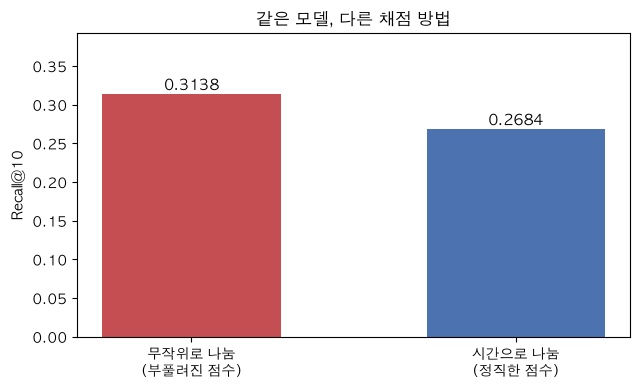

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
막대 = ax.bar(["무작위로 나눔\n(부풀려진 점수)", "시간으로 나눔\n(정직한 점수)"],
            [점수_무작위, 점수_시간순], color=["#C44E52", "#4C72B0"], width=0.55)
for b, v in zip(막대, [점수_무작위, 점수_시간순]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.4f}", ha="center", fontsize=11)
ax.set_ylabel("Recall@10")
ax.set_title("같은 모델, 다른 채점 방법")
ax.set_ylim(0, max(점수_무작위, 점수_시간순) * 1.25)
plt.tight_layout()
plt.show()

## 2. 데이터 누수

배우는 데 쓰면 안 되는 정보가 새어 들어가 점수를 부풀리는 것을 **데이터 누수**라고 부릅니다.
방금 본 것이 딱 그 경우입니다. 기록을 무작위로 섞으면 한 사람의 8월 기록이 학습 구간에 들어가고
3월 기록이 채점 구간에 들어가는 일이 생깁니다. 미래를 보고 과거를 맞힌 것입니다.

누수는 실무에서 **가장 자주 일어나는 사고**입니다. 그리고 발견하기 어렵습니다. 왜냐하면
**점수가 올라가기 때문**입니다. 점수가 떨어지면 원인을 찾아 나서지만, 점수가 좋아지면 그냥 넘어갑니다.

그래서 기억해 둘 것이 하나 있습니다. **점수가 갑자기 좋아지면 먼저 의심해야 합니다.**

## 3. 새로 온 사람에게는 무엇을 줄 것인가

문제가 하나 더 있습니다. 지금까지 우리는 전체 평균 하나만 보고 있었는데, 그 평균 뒤에 가려진
사람들이 있습니다. **이번 달에 처음 가입한 사람들**입니다.

담은 기록이 거의 없으니 취향을 짐작할 재료가 없습니다. 주력 섹터를 구하려고 해도 담은 종목이
두세 개뿐이면 그것이 취향인지 우연인지 알 수 없습니다. 이것을 **콜드스타트**라고 부릅니다.

신규 투자자와 기존 투자자를 나눠서 점수를 따로 재 봅니다.

In [6]:
신규 = set(users[users["is_newcomer"]]["user_id"])
print(f"마지막 달에 처음 나타난 신규 투자자 {len(신규)}명")

추천함수 = 무리별_추천_만들기(train_t)
점수_신규, n1 = recsys.recall_at_k(추천함수, train_t, test_t[test_t["user_id"].isin(신규)])
점수_기존, n2 = recsys.recall_at_k(추천함수, train_t, test_t[~test_t["user_id"].isin(신규)])

print(f"\n기존 투자자  Recall@10 = {점수_기존:.4f}   ({n2}명)")
print(f"신규 투자자  Recall@10 = {점수_신규:.4f}   ({n1}명)")
print(f"\n신규 투자자가 기존 투자자보다 {(점수_기존 - 점수_신규) / 점수_기존:.0%} 낮습니다.")

마지막 달에 처음 나타난 신규 투자자 15명



기존 투자자  Recall@10 = 0.2746   (251명)
신규 투자자  Recall@10 = 0.1653   (15명)

신규 투자자가 기존 투자자보다 40% 낮습니다.


전체 평균 하나만 보고 있었다면 이 사람들이 훨씬 나쁜 추천을 받고 있다는 사실을 모르고 지나쳤을 것입니다.

그러면 신규 투자자에게는 무엇을 주는 것이 좋을까요? 취향을 알 수 없으니 무리별 목록은 의미가 없습니다.
가장 단순한 대안은 **전체 인기 목록을 그냥 주는 것**입니다. 실제로 그 편이 나은지 재 봅니다.

In [7]:
전체인기 = list(train_t["item_id"].value_counts().index)
신규_test = test_t[test_t["user_id"].isin(신규)]

점수_인기순, _ = recsys.recall_at_k(lambda u, seen: recsys.take(전체인기, seen), train_t, 신규_test)

print(f"신규 투자자에게 무리별 목록   Recall@10 = {점수_신규:.4f}")
print(f"신규 투자자에게 전체 인기 목록 Recall@10 = {점수_인기순:.4f}")

if abs(점수_인기순 - 점수_신규) < 1e-9:
    # 왜 두 방법의 점수가 똑같이 나왔는지 확인합니다.
    학습에_있는_신규 = 신규 & set(train_t["user_id"])
    print(f"\n두 방법의 점수가 완전히 같습니다. 이유를 확인해 봅니다.")
    print(f"  신규 투자자 {len(신규)}명 중 학습 구간에 기록이 있는 사람: {len(학습에_있는_신규)}명")
    print()
    print("  신규 투자자는 마지막 달에 처음 나타났고, 그 마지막 달이 통째로 채점 구간입니다.")
    print("  그래서 학습 구간에는 이 사람들의 기록이 한 건도 없습니다. 주력 섹터를 구할 수도,")
    print("  무리에 배정할 수도 없으니 추천 함수가 자동으로 전체 인기 목록으로 넘어갑니다.")
    print("  즉 우리는 이미 신규 투자자에게 인기 목록을 주고 있었고, 그래서 두 점수가 같습니다.")
    print()
    print("  이것이 콜드스타트의 정확한 모습입니다. 무리로 나누는 방법 자체가 이 사람들에게는")
    print("  아무 효과가 없습니다. 기록이 없으면 어떤 개인화도 시작할 수 없기 때문입니다.")
elif 점수_인기순 > 점수_신규:
    print("\n전체 인기 목록을 주는 편이 낫습니다. 취향을 모를 때는 무리를 억지로 정하지 않는 것이 낫습니다.")
else:
    print("\n무리별 목록이 낫습니다. 기록이 적어도 아예 없는 것보다는 쓸모가 있다는 뜻입니다.")

신규 투자자에게 무리별 목록   Recall@10 = 0.1653
신규 투자자에게 전체 인기 목록 Recall@10 = 0.1653

두 방법의 점수가 완전히 같습니다. 이유를 확인해 봅니다.
  신규 투자자 15명 중 학습 구간에 기록이 있는 사람: 0명

  신규 투자자는 마지막 달에 처음 나타났고, 그 마지막 달이 통째로 채점 구간입니다.
  그래서 학습 구간에는 이 사람들의 기록이 한 건도 없습니다. 주력 섹터를 구할 수도,
  무리에 배정할 수도 없으니 추천 함수가 자동으로 전체 인기 목록으로 넘어갑니다.
  즉 우리는 이미 신규 투자자에게 인기 목록을 주고 있었고, 그래서 두 점수가 같습니다.

  이것이 콜드스타트의 정확한 모습입니다. 무리로 나누는 방법 자체가 이 사람들에게는
  아무 효과가 없습니다. 기록이 없으면 어떤 개인화도 시작할 수 없기 때문입니다.


정답이 하나가 아닙니다. 위험도가 중간인 종목만 골라 주는 방법도 있고, 가입할 때 몇 가지를 물어보는
방법도 있습니다. 각자 다른 방법을 시도해 보고 **왜 그 방법을 골랐는지 한 줄로 적어 보세요.**

In [8]:
recsys.record(3, "시간순 분할로 정직하게", 점수_시간순,
              note=f"모델은 2주차와 같다. 무작위로 나누면 {점수_무작위:.4f}가 나오는데 "
                   f"이는 미래를 보고 맞힌 부풀려진 점수다.")

레벨 3 · 시간순 분할로 정직하게 · Recall@10 = 0.2684


{'level': 3,
 'name': '시간순 분할로 정직하게',
 'recall_at_10': 0.2684,
 'note': '모델은 2주차와 같다. 무작위로 나누면 0.3138가 나오는데 이는 미래를 보고 맞힌 부풀려진 점수다.'}

## 오늘의 마무리

모델을 하나도 바꾸지 않았는데 점수가 떨어졌습니다. 지금까지 우리가 좋아하던 숫자 중 일부는
**미래를 미리 본 대가**였습니다. 앞으로 점수판에 적는 숫자는 시간으로 나눠서 잰 값만 씁니다.

그리고 평균 하나로는 보이지 않는 것이 있다는 것도 확인했습니다. 신규 투자자는 기존 투자자보다
훨씬 나쁜 추천을 받고 있었습니다.

이제 다음 문제로 넘어갈 차례입니다. 지금 우리 방식은 같은 무리에 속한 사람에게 모두 같은 목록을
줍니다. 그런데 반도체를 주로 담는 사람들 안에서도 어떤 사람은 장비주를, 어떤 사람은 소재주를
좋아합니다. 이런 차이는 섹터나 위험도 같은 겉으로 드러난 정보만으로는 나눌 수 없습니다.

다음 주에는 사람이 정한 규칙을 버리고, **함께 담은 사람들의 기록에서 모델이 스스로 취향을 찾아내게**
합니다. 점수가 크게 오릅니다.